In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from scipy.signal import savgol_filter

from preparation import load_and_prepare_data, handle_duplicate_values, handle_outliers, reindex_daily, handle_missing_values, smooth_data, merge_datasets, slice_by_dates

### Data preparation

In [29]:
# North site
insitu_df1 = load_and_prepare_data('../data/processed/in-situ/SDH1_daily-insitu-data.csv')
insitu_df1 = handle_duplicate_values(insitu_df1)
insitu_df1 = reindex_daily(insitu_df1)

# South site
insitu_df2 = load_and_prepare_data('../data/processed/in-situ/SDH2_daily-insitu-data.csv')
insitu_df2 = handle_duplicate_values(insitu_df2)
insitu_df2 = reindex_daily(insitu_df2)

In [30]:
# Point data - ZN
remote_df_p = load_and_prepare_data('../data/processed/satellites/SDH1G30P01_sentinel2_bands_indices_TCT_202405-202602.csv')
remote_df_p = handle_duplicate_values(remote_df_p)
remote_df_p = reindex_daily(remote_df_p)
remote_df_p = handle_outliers(remote_df_p, 3.0)
remote_df_p = handle_missing_values(remote_df_p, 'time')
remote_df_p = smooth_data(remote_df_p, None, 11, 2)

# Areal data - ZN
remote_df_a = load_and_prepare_data('../data/processed/satellites/Sentinel2_bands_indices_TCT_30m_202405-202604.csv')
remote_df_a = remote_df_a.drop(columns=['system:index', '.geo'])
remote_df_a = handle_duplicate_values(remote_df_a)
remote_df_a = reindex_daily(remote_df_a)
remote_df_a = handle_outliers(remote_df_a, 3.0)
remote_df_a = handle_missing_values(remote_df_a, 'time')
remote_df_a = smooth_data(remote_df_a, None, 11, 2)

In [31]:
# Point data - ZN
fused_df_p = merge_datasets(insitu_df1, remote_df_p)
fused_df_p = slice_by_dates(fused_df_p, '2024-05-20', '2025-01-01')
z_df_p = fused_df_p.apply(zscore, nan_policy='omit')

# Areal data - ZN
fused_df_a = merge_datasets(insitu_df1, remote_df_a)
fused_df_a = slice_by_dates(fused_df_a, '2024-05-20', '2025-01-01')
z_df_a = fused_df_a.apply(zscore, nan_policy='omit')

/opt/miniconda3/envs/dataScience/lib/python3.13/site-packages/pandas/core/apply.py:1183: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  results[i] = self.func(v, *self.args, **self.kwargs)
/opt/miniconda3/envs/dataScience/lib/python3.13/site-packages/pandas/core/apply.py:1183: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  results[i] = self.func(v, *self.args, **self.kwargs)
/opt/miniconda3/envs/dataScience/lib/python3.13/site-packages/pandas/core/apply.py:1183: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  results[i] = self.func(v, *self.args, **self.kwargs)
/opt/miniconda3/envs/dataScience/lib/python3.13/site-pa

### Plots

Comparación datos puntuales vs areales

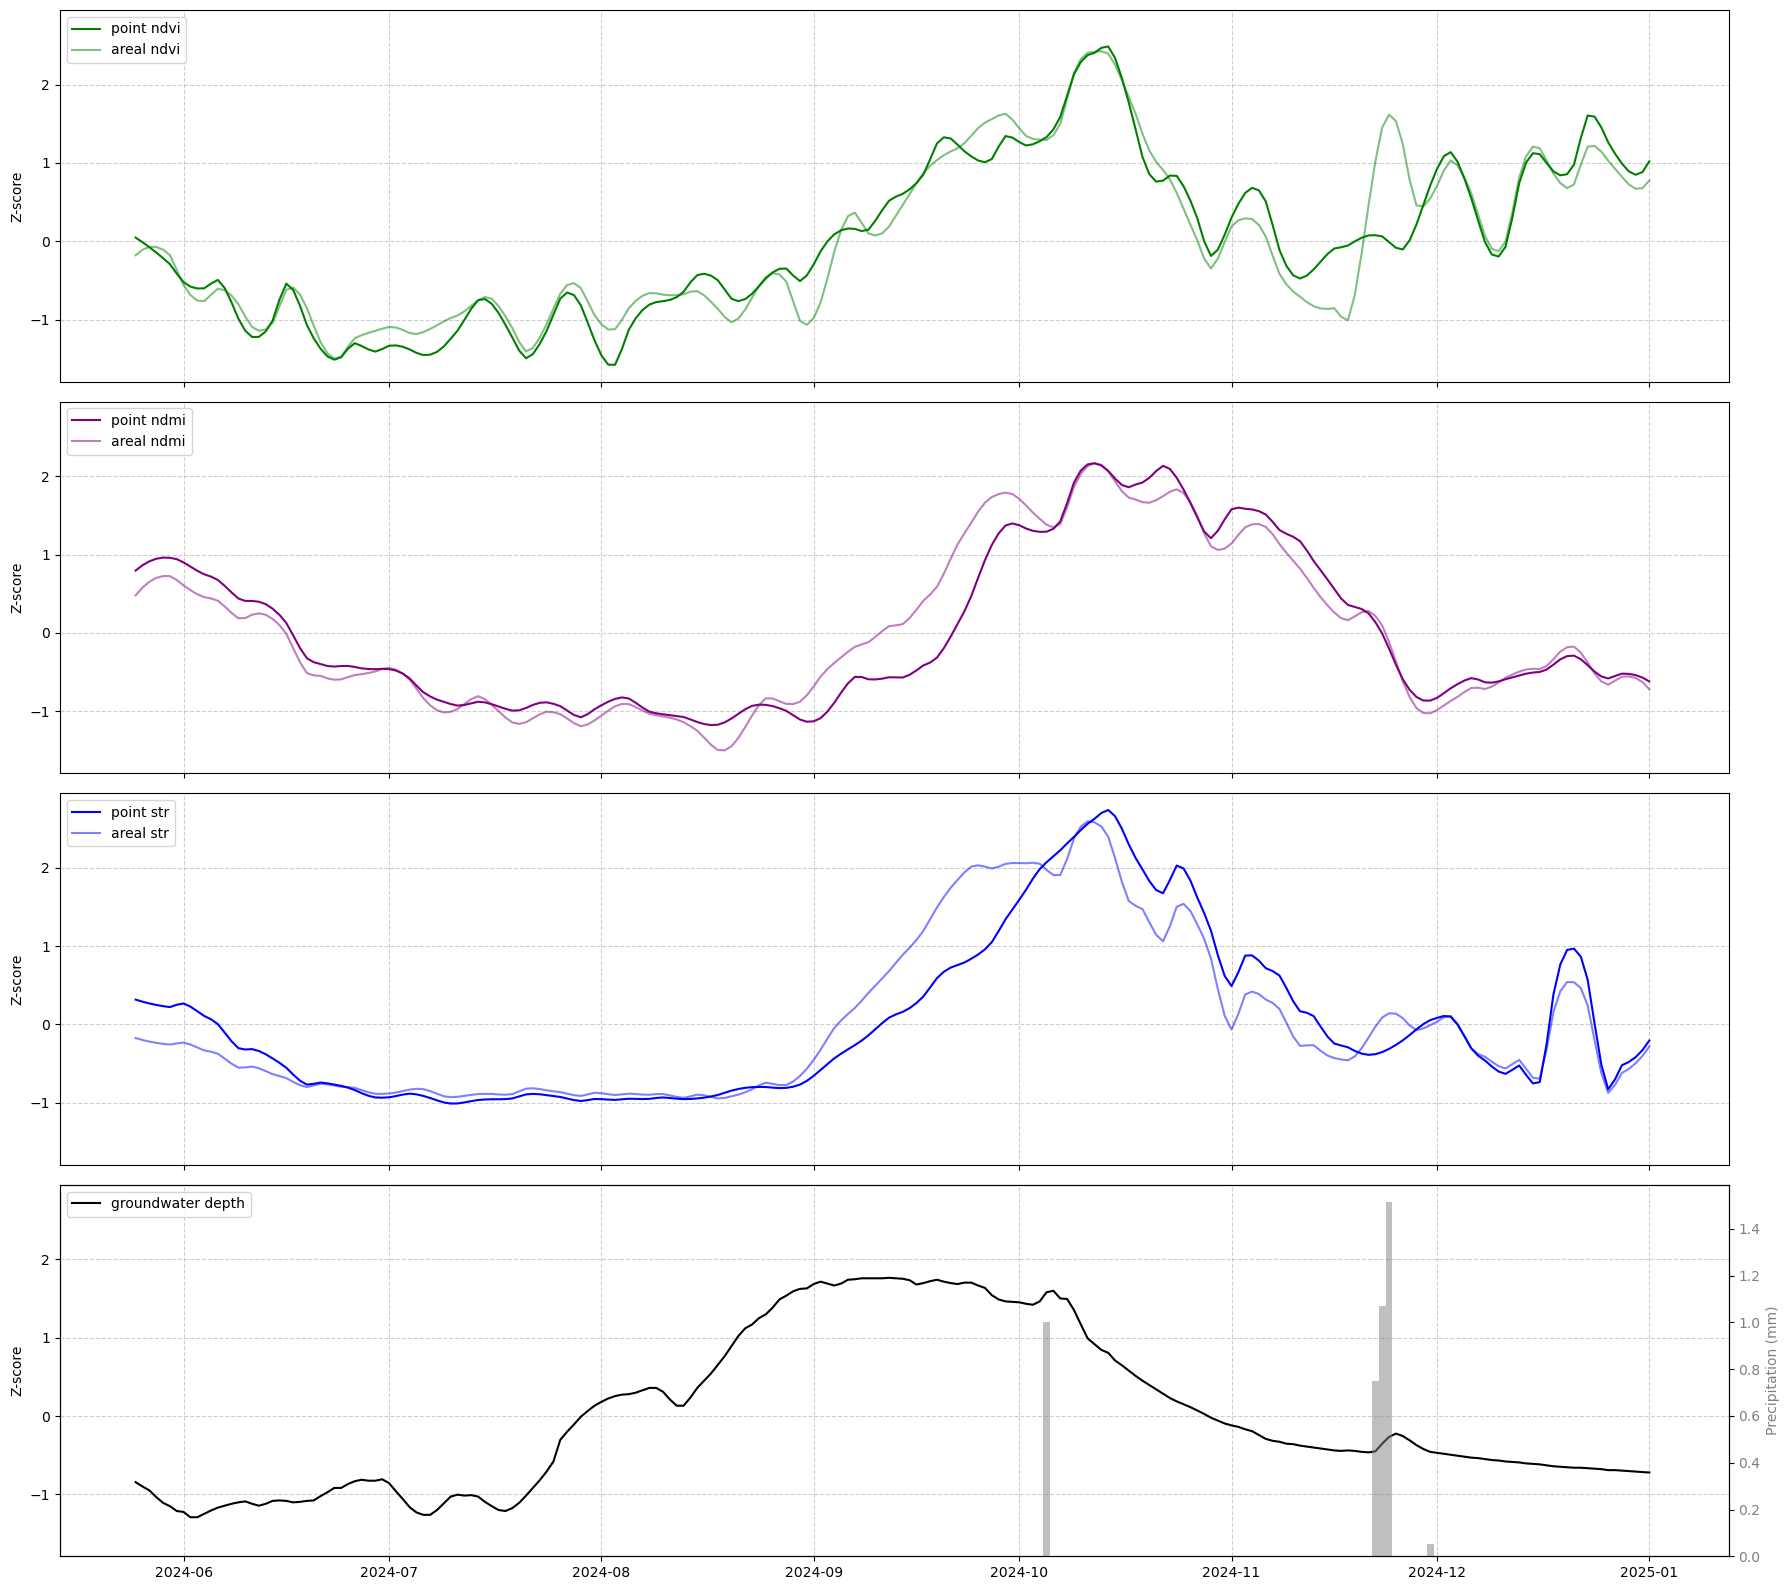

In [32]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(18,16), sharex=True, sharey=True)

ax1.plot(z_df_p.index, z_df_p['s2_ndvi'], label='point ndvi', c='green', alpha=1)
ax1.plot(z_df_a.index, z_df_a['salt_ndvi'], label='areal ndvi', c='green', alpha=0.5)
ax1.set_ylabel('Z-score')
ax1.legend(loc='upper left')
ax1.grid(linestyle='--', alpha=0.6)

ax2.plot(z_df_p.index, z_df_p['s2_ndmi'], label='point ndmi', c='purple', alpha=1)
ax2.plot(z_df_a.index, z_df_a['salt_ndmi'], label='areal ndmi', c='purple', alpha=0.5)
ax2.set_ylabel('Z-score')
ax2.legend(loc='upper left')
ax2.grid(linestyle='--', alpha=0.6)

ax3.plot(z_df_p.index, z_df_p['s2_str'], label='point str', c='blue', alpha=1)
ax3.plot(z_df_a.index, z_df_a['salt_str'], label='areal str', c='blue', alpha=0.5)
ax3.set_ylabel('Z-score')
ax3.legend(loc='upper left')
ax3.grid(linestyle='--', alpha=0.6)

ax4.plot(z_df_p.index, z_df_p['SDH1PS01_gw-depth_m'], label='groundwater depth', c='black', alpha=1)
ax4.set_ylabel('Z-score')
ax4.legend(loc='upper left')
ax4.grid(linestyle='--', alpha=0.6)

ax5 = ax4.twinx()
ax5.bar(fused_df_p.index, fused_df_p['ATMOS41_precipitation_mm'], width=1, color='gray', alpha=0.5, label='Precipitation (mm)')
ax5.set_ylabel('Precipitation (mm)', color='gray')
ax5.tick_params(axis='y', labelcolor='gray')

plt.tight_layout()
plt.show()

NDVI de diferentes coberturas - datos areales

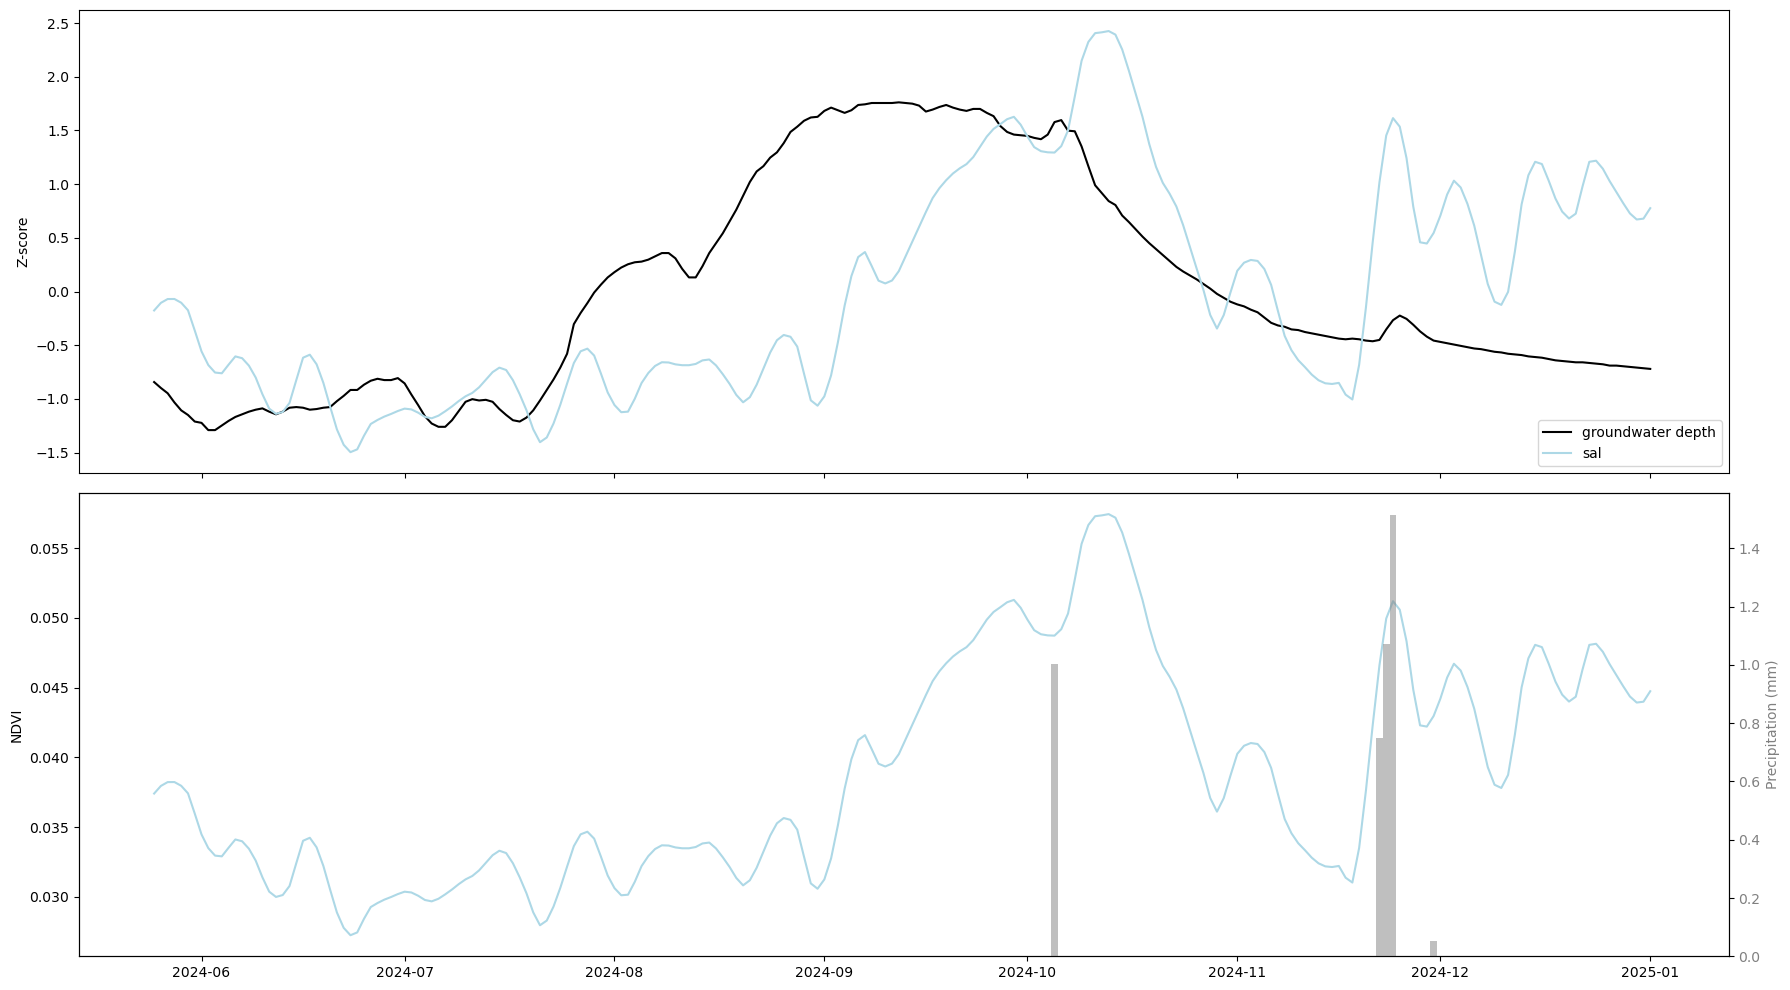

In [33]:
# Figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

# Plot superior
ax1.plot(z_df_a.index, z_df_a['SDH1PS01_gw-depth_m'], label='groundwater depth', c='black')
#ax1.plot(z_df_a.index, z_df_a['bof_ndvi'], label='bofedal', c='green', alpha=0.5)
#ax1.plot(z_df_a.index, z_df_a['paj_ndvi'], label='pajonal', c='orange', alpha=0.5)
ax1.plot(z_df_a.index, z_df_a['salt_ndvi'], label='sal', c='lightblue', alpha=1)
ax1.set_ylabel('Z-score')
ax1.legend(loc='lower right')

# Plot inferior
#ax2.plot(fused_df_a.index, fused_df_a['bof_ndvi'], label='bofedal', c='green', alpha=0.5)
#ax2.plot(fused_df_a.index, fused_df_a['paj_ndvi'], label='pajonal', c='orange', alpha=0.5)
ax2.plot(fused_df_a.index, fused_df_a['salt_ndvi'], label='sal', c='lightblue', alpha=1)
ax2.set_ylabel('NDVI')

# Eje Y secundario (pp)
ax3 = ax2.twinx()
ax3.bar(fused_df_p.index, fused_df_p['ATMOS41_precipitation_mm'], width=1, color='gray', alpha=0.5, label='Precipitation (mm)')
ax3.set_ylabel('Precipitation (mm)', color='gray')
ax3.tick_params(axis='y', labelcolor='gray')

plt.tight_layout()
plt.show()

NDMI de diferentes coberturas - datos areales

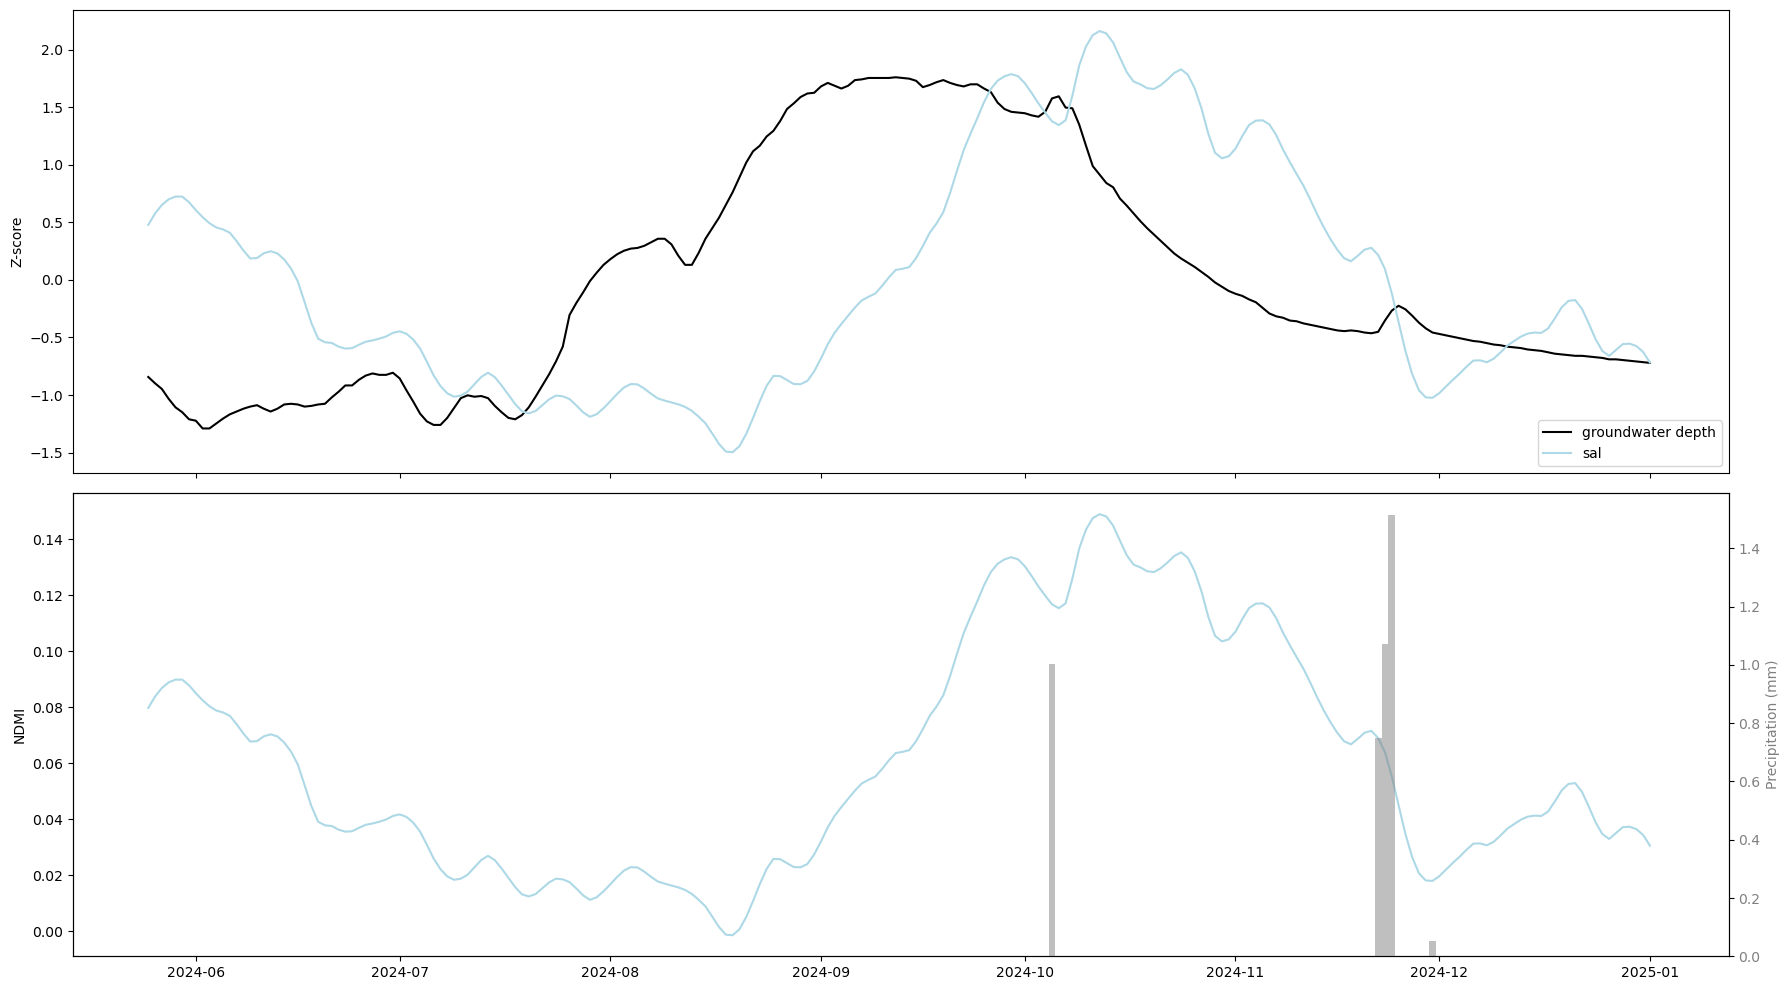

In [34]:
# Figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

# Plot superior
ax1.plot(z_df_a.index, z_df_a['SDH1PS01_gw-depth_m'], label='groundwater depth', c='black')
#ax1.plot(z_df_a.index, z_df_a['bof_ndmi'], label='bofedal', c='green', alpha=0.5)
#ax1.plot(z_df_a.index, z_df_a['paj_ndmi'], label='pajonal', c='orange', alpha=0.5)
ax1.plot(z_df_a.index, z_df_a['salt_ndmi'], label='sal', c='lightblue', alpha=1)
ax1.set_ylabel('Z-score')
ax1.legend(loc='lower right')

# Plot inferior
#ax2.plot(fused_df_a.index, fused_df_a['bof_ndmi'], label='bofedal', c='green', alpha=0.5)
#ax2.plot(fused_df_a.index, fused_df_a['paj_ndmi'], label='pajonal', c='orange', alpha=0.5)
ax2.plot(fused_df_a.index, fused_df_a['salt_ndmi'], label='sal', c='lightblue', alpha=1)
ax2.set_ylabel('NDMI')

# Eje Y secundario (pp)
ax3 = ax2.twinx()
ax3.bar(fused_df_p.index, fused_df_p['ATMOS41_precipitation_mm'], width=1, color='gray', alpha=0.5, label='Precipitation (mm)')
ax3.set_ylabel('Precipitation (mm)', color='gray')
ax3.tick_params(axis='y', labelcolor='gray')

plt.tight_layout()
plt.show()

STR de diferentes coberturas - datos areales

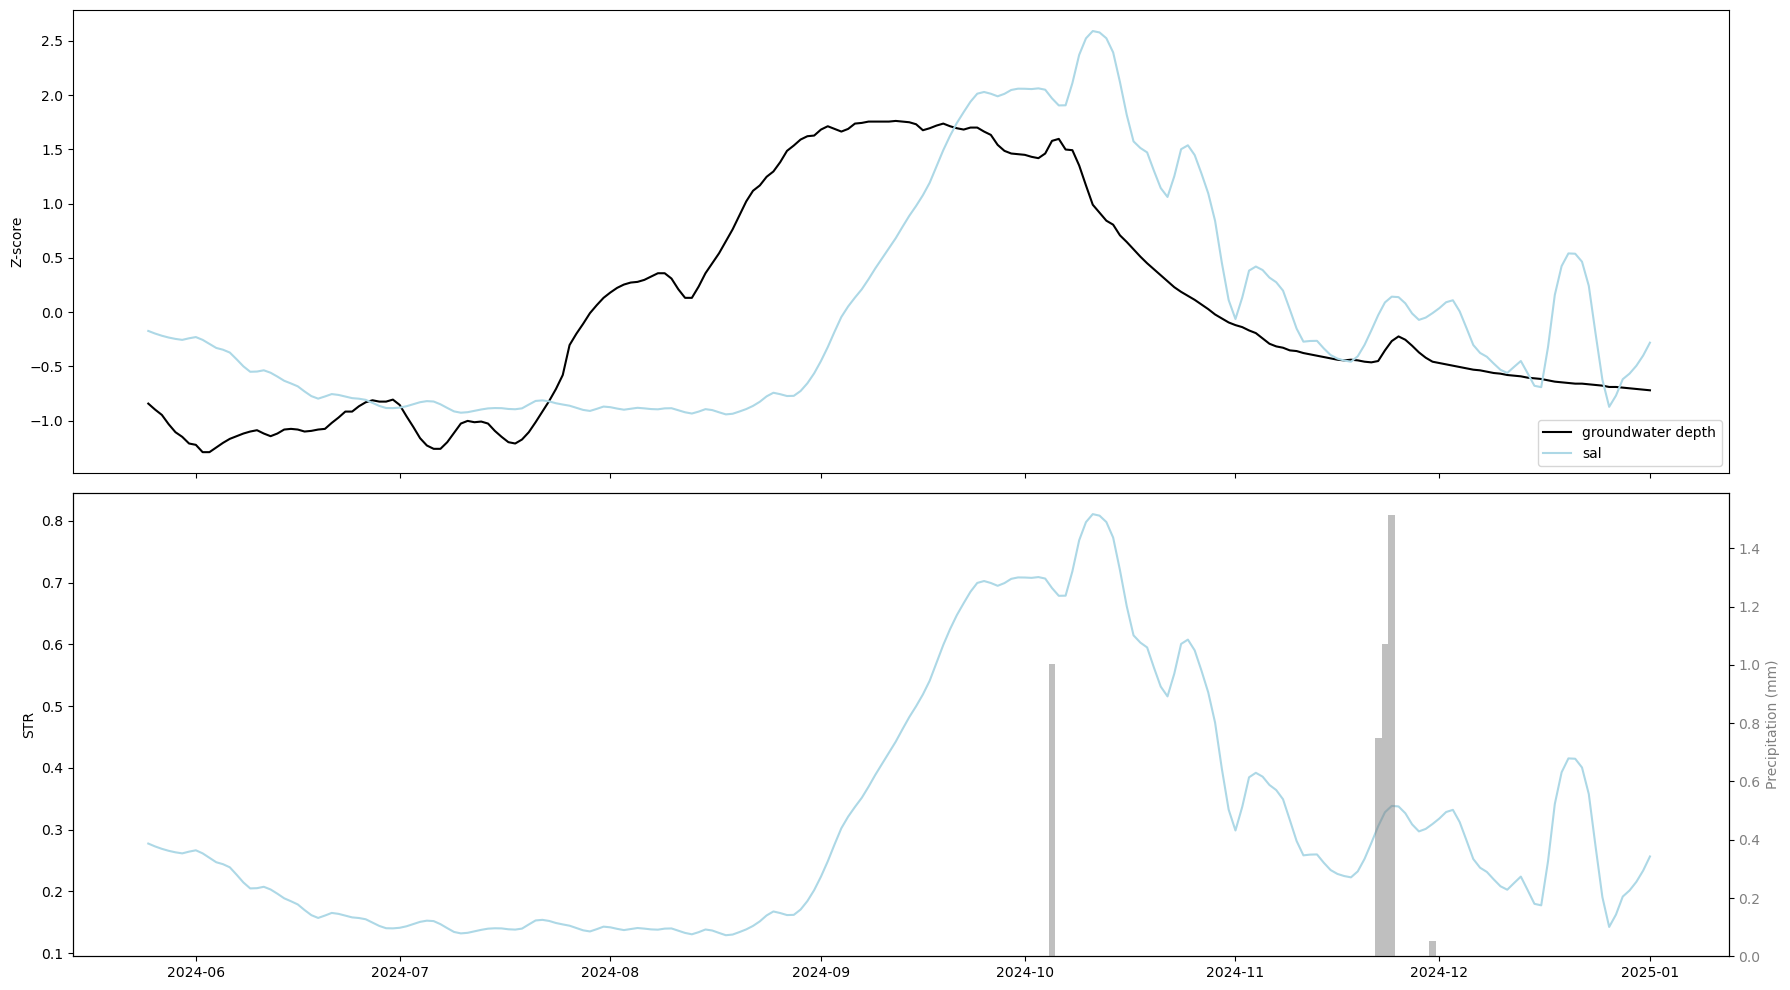

In [35]:
# Figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

# Plot superior
ax1.plot(z_df_a.index, z_df_a['SDH1PS01_gw-depth_m'], label='groundwater depth', c='black')
#ax1.plot(z_df_a.index, z_df_a['bof_str'], label='bofedal', c='green', alpha=0.5)
#ax1.plot(z_df_a.index, z_df_a['paj_str'], label='pajonal', c='orange', alpha=0.5)
ax1.plot(z_df_a.index, z_df_a['salt_str'], label='sal', c='lightblue', alpha=1)
ax1.set_ylabel('Z-score')
ax1.legend(loc='lower right')

# Plot inferior
#ax2.plot(fused_df_a.index, fused_df_a['bof_str'], label='bofedal', c='green', alpha=0.5)
#ax2.plot(fused_df_a.index, fused_df_a['paj_str'], label='pajonal', c='orange', alpha=0.5)
ax2.plot(fused_df_a.index, fused_df_a['salt_str'], label='sal', c='lightblue', alpha=1)
ax2.set_ylabel('STR')

# Eje Y secundario (pp)
ax3 = ax2.twinx()
ax3.bar(fused_df_p.index, fused_df_p['ATMOS41_precipitation_mm'], width=1, color='gray', alpha=0.5, label='Precipitation (mm)')
ax3.set_ylabel('Precipitation (mm)', color='gray')
ax3.tick_params(axis='y', labelcolor='gray')

plt.tight_layout()
plt.show()

Brightness en diferentes coberturas

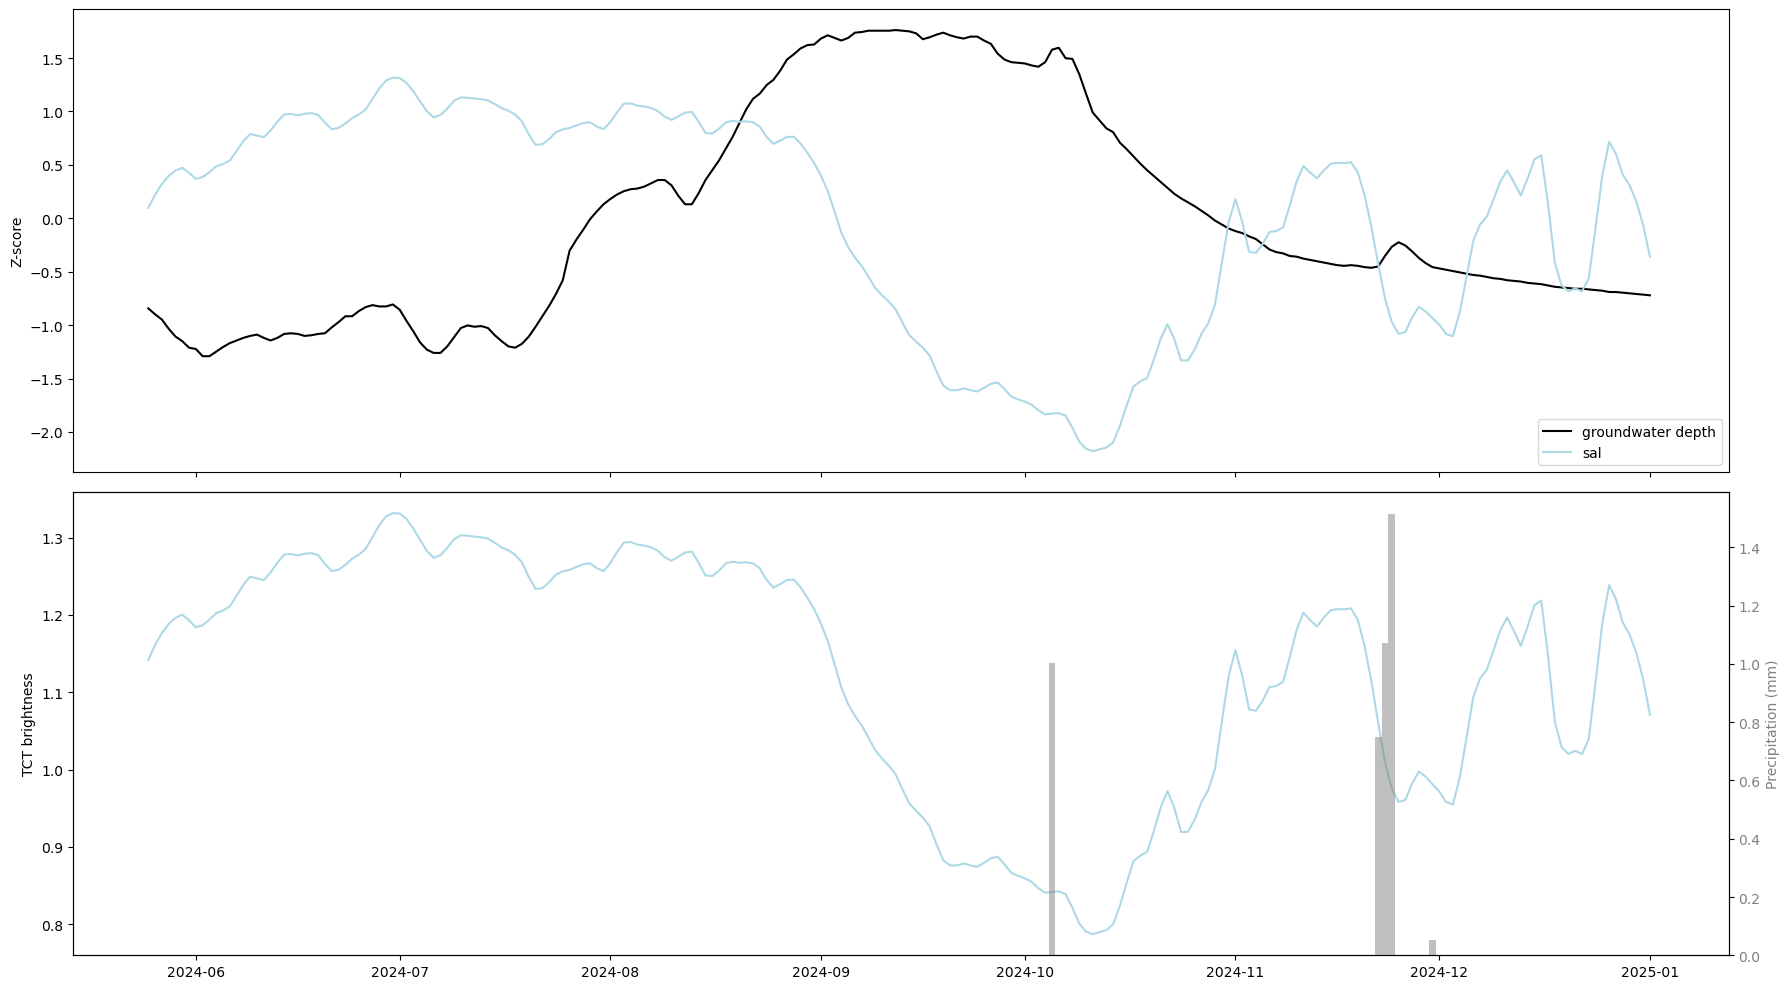

In [36]:
# Figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

# Plot superior
ax1.plot(z_df_a.index, z_df_a['SDH1PS01_gw-depth_m'], label='groundwater depth', c='black')
#ax1.plot(z_df_a.index, z_df_a['bof_brightness'], label='bofedal', c='green', alpha=0.5)
#ax1.plot(z_df_a.index, z_df_a['paj_brightness'], label='pajonal', c='orange', alpha=0.5)
ax1.plot(z_df_a.index, z_df_a['salt_brightness'], label='sal', c='lightblue', alpha=1)
ax1.set_ylabel('Z-score')
ax1.legend(loc='lower right')

# Plot inferior
#ax2.plot(fused_df_a.index, fused_df_a['bof_brightness'], label='bofedal', c='green', alpha=0.5)
#ax2.plot(fused_df_a.index, fused_df_a['paj_brightness'], label='pajonal', c='orange', alpha=0.5)
ax2.plot(fused_df_a.index, fused_df_a['salt_brightness'], label='sal', c='lightblue', alpha=1)
ax2.set_ylabel('TCT brightness')

# Eje Y secundario (pp)
ax3 = ax2.twinx()
ax3.bar(fused_df_p.index, fused_df_p['ATMOS41_precipitation_mm'], width=1, color='gray', alpha=0.5, label='Precipitation (mm)')
ax3.set_ylabel('Precipitation (mm)', color='gray')
ax3.tick_params(axis='y', labelcolor='gray')

plt.tight_layout()
plt.show()

MNDWI en diferentes coberturas

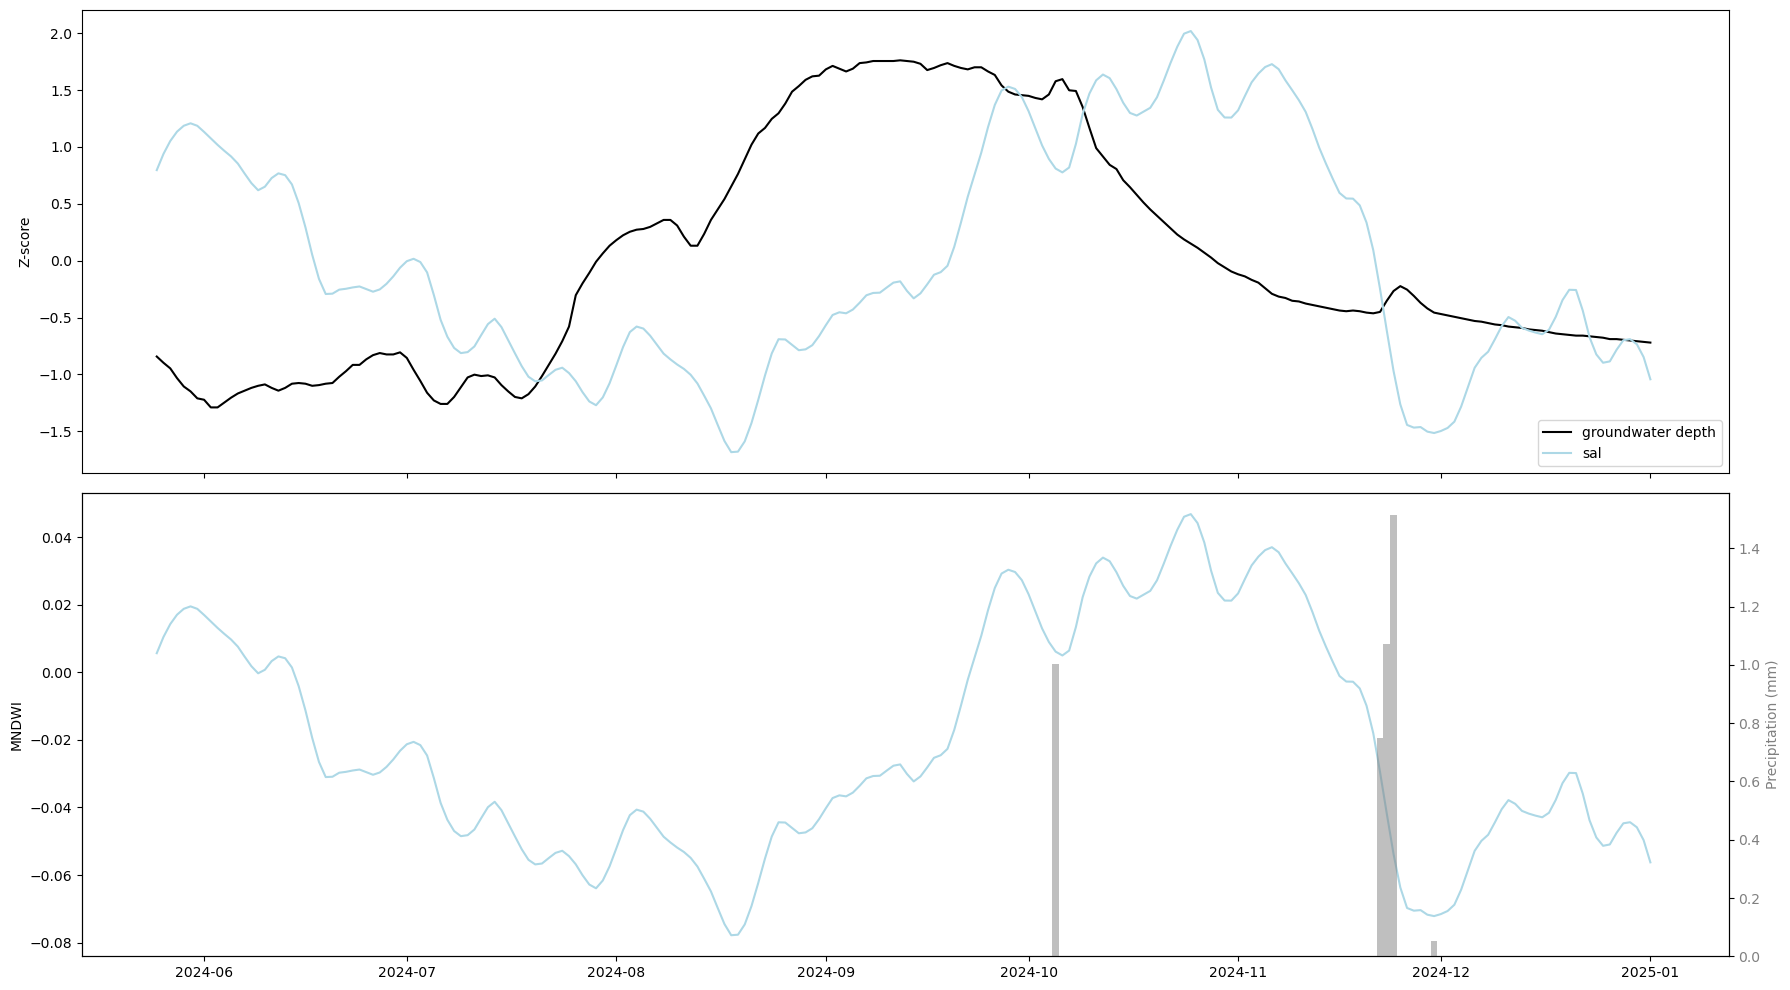

In [37]:
# Figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

# Plot superior
ax1.plot(z_df_a.index, z_df_a['SDH1PS01_gw-depth_m'], label='groundwater depth', c='black')
#ax1.plot(z_df_a.index, z_df_a['bof_mndwi'], label='bofedal', c='green', alpha=0.5)
#ax1.plot(z_df_a.index, z_df_a['paj_mndwi'], label='pajonal', c='orange', alpha=0.5)
ax1.plot(z_df_a.index, z_df_a['salt_mndwi'], label='sal', c='lightblue', alpha=1)
ax1.set_ylabel('Z-score')
ax1.legend(loc='lower right')

# Plot inferior
#ax2.plot(fused_df_a.index, fused_df_a['bof_mndwi'], label='bofedal', c='green', alpha=0.5)
#ax2.plot(fused_df_a.index, fused_df_a['paj_mndwi'], label='pajonal', c='orange', alpha=0.5)
ax2.plot(fused_df_a.index, fused_df_a['salt_mndwi'], label='sal', c='lightblue', alpha=1)
ax2.set_ylabel('MNDWI')

# Eje Y secundario (pp)
ax3 = ax2.twinx()
ax3.bar(fused_df_p.index, fused_df_p['ATMOS41_precipitation_mm'], width=1, color='gray', alpha=0.5, label='Precipitation (mm)')
ax3.set_ylabel('Precipitation (mm)', color='gray')
ax3.tick_params(axis='y', labelcolor='gray')

plt.tight_layout()
plt.show()

MNDWI en cuerpos de agua - datos areales

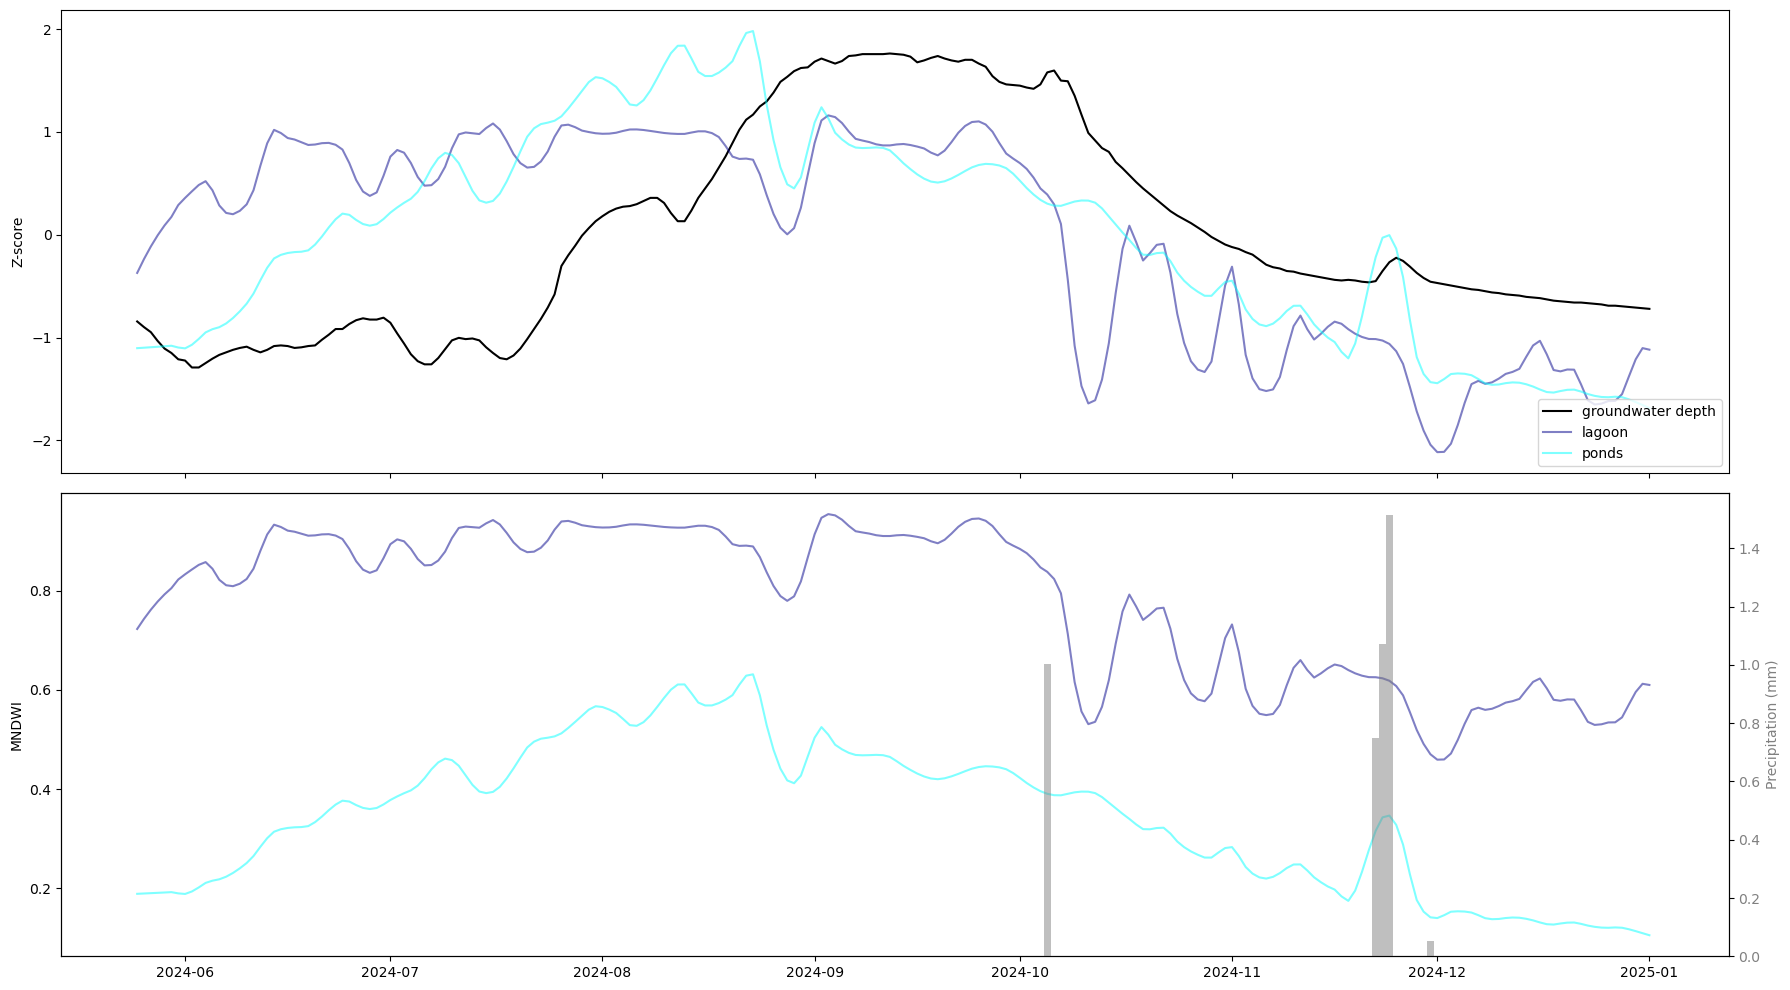

In [38]:
# Figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

# Plot superior
ax1.plot(z_df_a.index, z_df_a['SDH1PS01_gw-depth_m'], label='groundwater depth', c='black')
ax1.plot(z_df_a.index, z_df_a['wat1_mndwi'], label='lagoon', c='darkblue', alpha=0.5)
ax1.plot(z_df_a.index, z_df_a['wat2_mndwi'], label='ponds', c='cyan', alpha=0.5)
ax1.set_ylabel('Z-score')
ax1.legend(loc='lower right')

# Plot inferior
ax2.plot(fused_df_a.index, fused_df_a['wat1_mndwi'], label='lagoon', c='darkblue', alpha=0.5)
ax2.plot(fused_df_a.index, fused_df_a['wat2_mndwi'], label='ponds', c='cyan', alpha=0.5)
ax2.set_ylabel('MNDWI')

# Eje Y secundario (pp)
ax3 = ax2.twinx()
ax3.bar(fused_df_p.index, fused_df_p['ATMOS41_precipitation_mm'], width=1, color='gray', alpha=0.5, label='Precipitation (mm)')
ax3.set_ylabel('Precipitation (mm)', color='gray')
ax3.tick_params(axis='y', labelcolor='gray')

plt.tight_layout()
plt.show()

MNDWI vs área total de agua en SDH

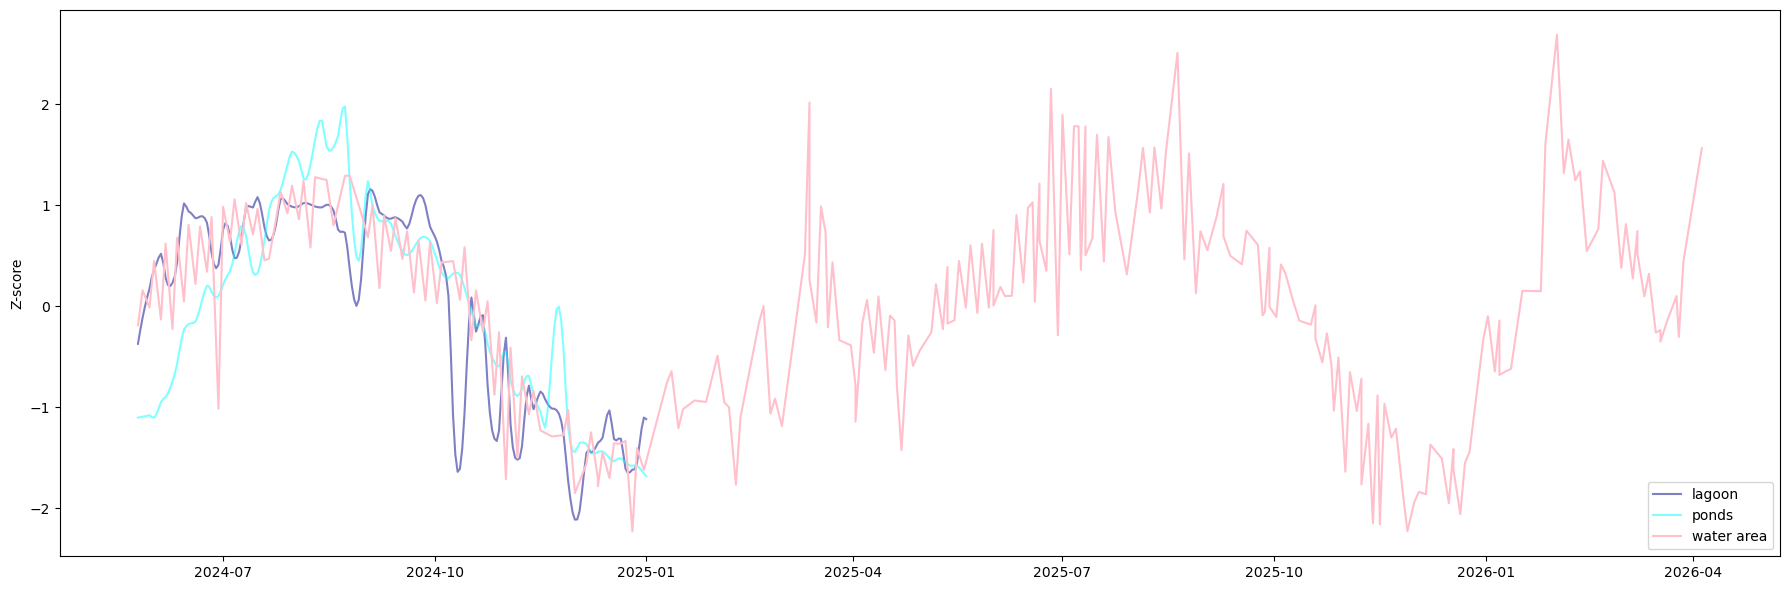

In [39]:
waterArea = load_and_prepare_data('../data/processed/satellites/SDH_water_area_2024-05_2026-04.csv')
waterAreaZ = waterArea.apply(zscore)

fig, ax = plt.subplots(figsize=(18, 6))
ax.plot(z_df_a.index, z_df_a['wat1_mndwi'], label='lagoon', c='darkblue', alpha=0.5)
ax.plot(z_df_a.index, z_df_a['wat2_mndwi'], label='ponds', c='cyan', alpha=0.5)
ax.plot(waterAreaZ.index, waterAreaZ['water_sqKm'], label='water area', c='pink', alpha=1)

ax.legend(loc='lower right')
ax.set_ylabel('Z-score')

plt.tight_layout()
plt.show()

Brightness en coberturas de suelo

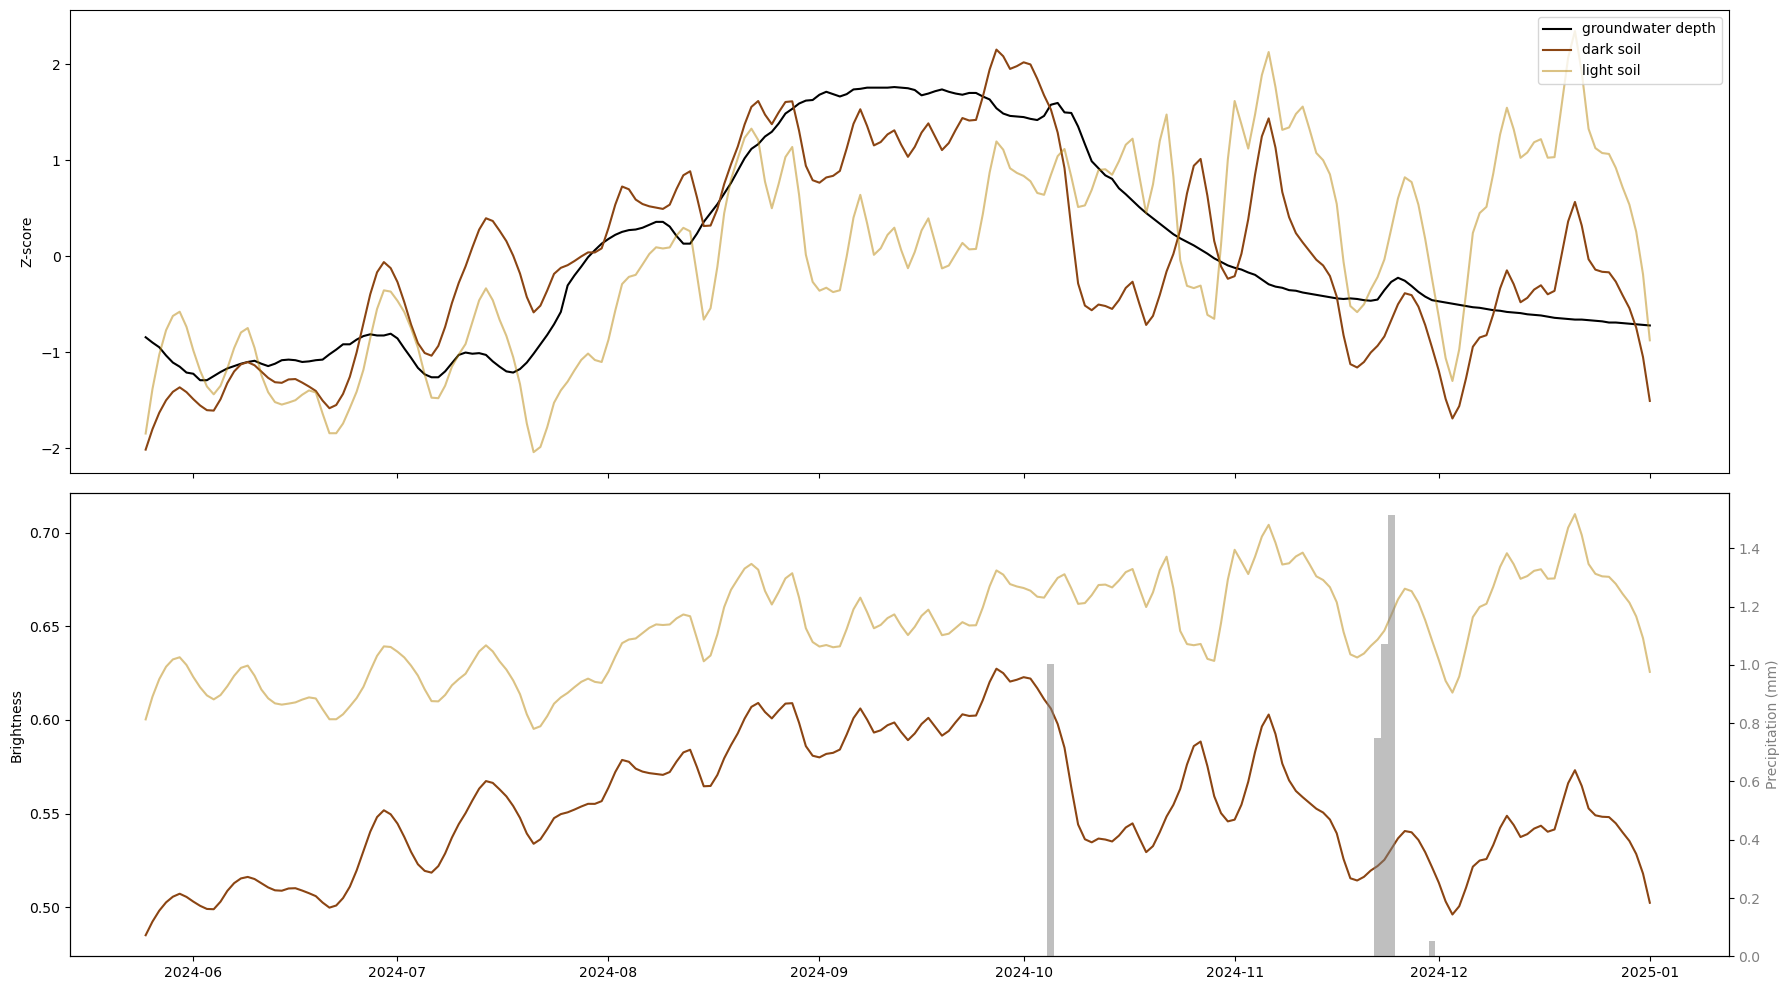

In [40]:
# Figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

# Plot superior
ax1.plot(z_df_a.index, z_df_a['SDH1PS01_gw-depth_m'], label='groundwater depth', c='black')
ax1.plot(z_df_a.index, z_df_a['soil1_brightness'], label='dark soil', c='saddlebrown', alpha=1)
ax1.plot(z_df_a.index, z_df_a['soil2_brightness'], label='light soil', c='darkgoldenrod', alpha=0.5)
ax1.set_ylabel('Z-score')
ax1.legend(loc='upper right')

# Plot inferior
ax2.plot(fused_df_a.index, fused_df_a['soil1_brightness'], label='dark soil', c='saddlebrown', alpha=1)
ax2.plot(fused_df_a.index, fused_df_a['soil2_brightness'], label='light soil', c='darkgoldenrod', alpha=0.5)
ax2.set_ylabel('Brightness')

# Eje Y secundario (pp)
ax3 = ax2.twinx()
ax3.bar(fused_df_p.index, fused_df_p['ATMOS41_precipitation_mm'], width=1, color='gray', alpha=0.5, label='Precipitation (mm)')
ax3.set_ylabel('Precipitation (mm)', color='gray')
ax3.tick_params(axis='y', labelcolor='gray')

plt.tight_layout()
plt.show()